In [1]:
!pip install requests beautifulsoup4 pandas networkx matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from urllib.parse import urljoin

In [3]:
articles = [
    "Artificial_intelligence",
    "Machine_learning",
    "Deep_learning",
    "Artificial_neural_network",
    "Natural_language_processing",
    "Computer_vision",
    "Generative_artificial_intelligence",
    "Large_language_model",
    "ChatGPT",
    "Transformer_(deep_learning_architecture)"
]

In [5]:
base_url = "https://en.wikipedia.org/wiki/"

edges = []

headers = {
    "User-Agent": "Mozilla/5.0"
}

for article in articles:
    url = base_url + article

    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    for link in soup.find_all("a", href=True):
        href = link["href"]

        if "/wiki/" in href:
            linked_article = href.split("/wiki/")[-1].split("#")[0]

            if linked_article in articles and linked_article != article:
                edges.append((article, linked_article))

# Remove duplicate edges
edges = list(set(edges))

print("Number of links collected:", len(edges))
print(edges[:10])

Number of links collected: 74
[('Generative_artificial_intelligence', 'Machine_learning'), ('Machine_learning', 'ChatGPT'), ('Computer_vision', 'Large_language_model'), ('Natural_language_processing', 'Artificial_intelligence'), ('Large_language_model', 'Machine_learning'), ('Deep_learning', 'Machine_learning'), ('Transformer_(deep_learning_architecture)', 'ChatGPT'), ('Natural_language_processing', 'Transformer_(deep_learning_architecture)'), ('Artificial_neural_network', 'Machine_learning'), ('Generative_artificial_intelligence', 'Computer_vision')]


In [6]:
G = nx.DiGraph()

# Add all articles as nodes
G.add_nodes_from(articles)

# Add the Wikipedia hyperlinks as directed edges
G.add_edges_from(edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 10
Number of edges: 74


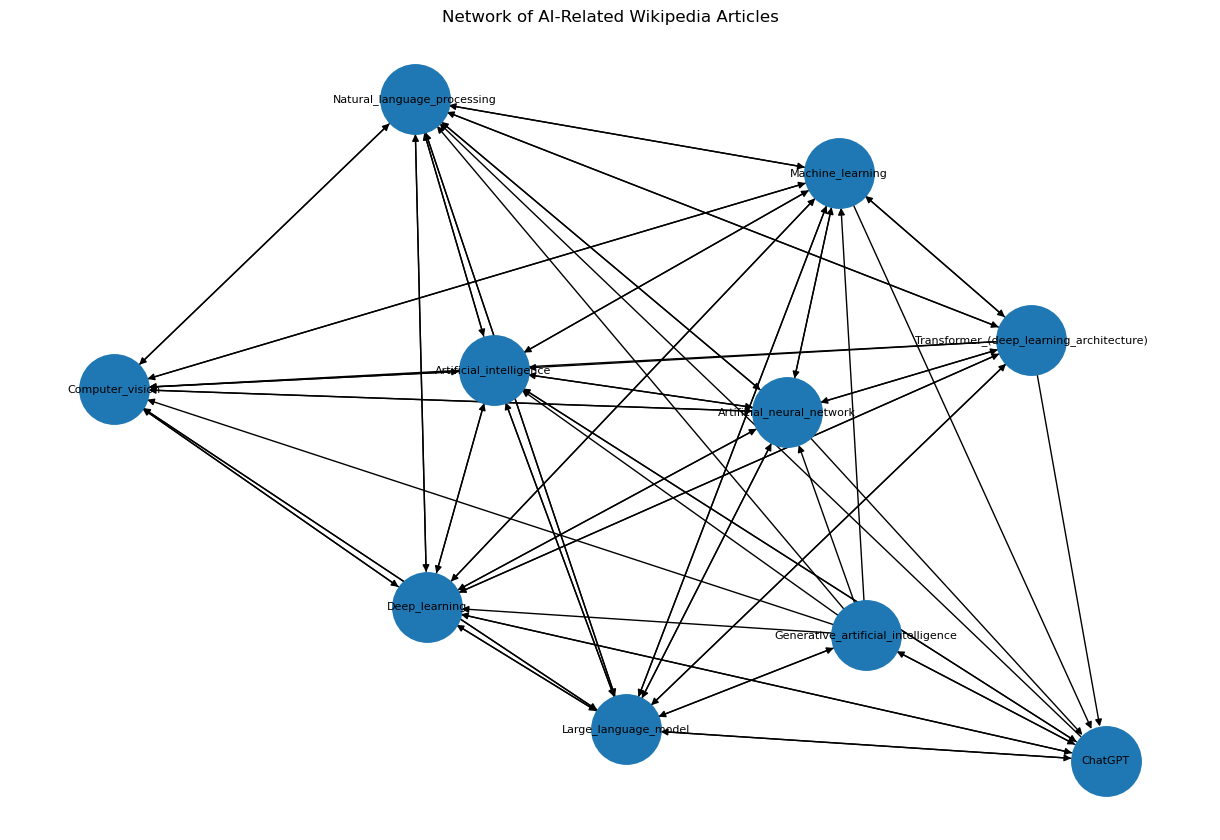

In [7]:
plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=8,
    arrows=True
)

plt.title("Network of AI-Related Wikipedia Articles")
plt.show()

In [8]:
pagerank = nx.pagerank(G)

pagerank_df = pd.DataFrame(
    list(pagerank.items()),
    columns=["Article", "PageRank"]
)

pagerank_df = pagerank_df.sort_values(
    by="PageRank",
    ascending=False
)

pagerank_df

,Article,PageRank
7,Large_language_model,0.121261
2,Deep_learning,0.119967
4,Natural_language_processing,0.118343
0,Artificial_intelligence,0.118343
3,Artificial_neural_network,0.106340
1,Machine_learning,0.106340
5,Computer_vision,0.103042
8,ChatGPT,0.088671
9,Transformer_(deep_learning_architecture),0.076166
6,Generative_artificial_intelligence,0.041527


In [9]:
indegree_data = []

for article in G.nodes():
    indegree_data.append({
        "Article": article,
        "Incoming_Links": G.in_degree(article),
        "Outgoing_Links": G.out_degree(article),
        "PageRank": pagerank[article]
    })

results_df = pd.DataFrame(indegree_data)

results_df = results_df.sort_values(
    by="PageRank",
    ascending=False
).reset_index(drop=True)

results_df

,Article,Incoming_Links,Outgoing_Links,PageRank
0,Large_language_model,9,9,0.121261
1,Deep_learning,9,8,0.119967
2,Natural_language_processing,9,7,0.118343
3,Artificial_intelligence,9,7,0.118343
4,Artificial_neural_network,8,8,0.106340
5,Machine_learning,8,8,0.106340
6,Computer_vision,8,6,0.103042
7,ChatGPT,7,5,0.088671
8,Transformer_(deep_learning_architecture),5,8,0.076166
9,Generative_artificial_intelligence,2,8,0.041527


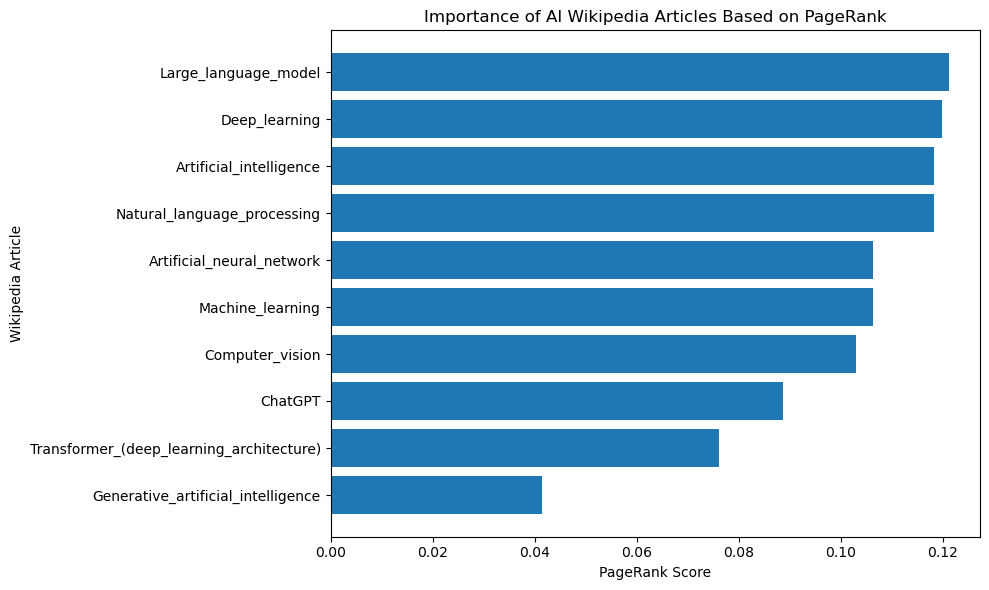

In [10]:
plot_df = results_df.sort_values(
    by="PageRank",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Article"],
    plot_df["PageRank"]
)

plt.xlabel("PageRank Score")
plt.ylabel("Wikipedia Article")
plt.title("Importance of AI Wikipedia Articles Based on PageRank")

plt.tight_layout()
plt.show()